# 4a — Hazard Maps: Current Exposure

## Purpose
Generate and save hazard-exposure maps for the Serbian road network based on current (historical) hazard data. Hazard is applied to the Serbian part of the road network only; Kosovo roads appear in grey on all maps.

## Inputs
| File | Description |
|------|-------------|
| `input_files/ne_10m_admin_0_countries.shp` | Natural Earth country boundaries (Serbia + Kosovo outlines) |
| `input_files/Deonice_Februar_2025.shp` | Baseline road network |
| `input_files/Europe_RP100_filled_depth.tif` | European fluvial flood depth raster (100-year return period) |
| `intermediate_results/parquet/network/main_network_directed.parquet` | Processed road network for flood assignment |
| `input_files/snezni_nanosi_studije.shp` | Snow-drift segment locations and lengths |
| `input_files/Nestabilne_pojave.shp` | Landslide occurrence points (all types; filtered to *Klizište* in code) |
| `input_files/wildfire risk/stepen ugrozenosti od pozara Srbijasume.tif` | Wildfire susceptibility raster |
| `input_files/landslide_susceptibility.tif` | Landslide susceptibility raster (discrete classes 2/4/6/8/10) |

## Outputs
| File | Description |
|------|-------------|
| `figures/flood_depth_map.png` | Flood depth raster map |
| `figures/flood_depth_roads.png` | Roads coloured by flood exposure |
| `figures/snow_drift_map.png` | Snow-drift segments by length class |
| `figures/landslides_map_by_year.png` | Landslide points by recording year |
| `figures/binary_wildfire_risk_map.png` | Binary wildfire susceptibility raster |
| `figures/wildfire_risk_AB.png` | Two-panel: wildfire raster (A) and exposed roads (B) |
| `figures/landslide_susceptibility_map.png` | Landslide susceptibility raster |
| `intermediate_results/parquet/hazard_exposure/flood_depth_roads.parquet` | Road network with flood class (EPSG:6316) |
| `intermediate_results/parquet/hazard_exposure/wildfire_risk_roads.parquet` | Road network with wildfire risk flag (EPSG:6316) |
| `intermediate_results/database/hazard_exposure/hazard_exposure.gdb` | GDB layers: `flood_depth_roads`, `wildfire_risk_roads` |

## Key Processing Steps
1. **Load country boundaries** — Natural Earth Serbia + Kosovo polygons; clip road network to each
2. **Flood depth map** — clip European flood raster to Serbia bounding box; plot with blue colormap
3. **Flood depth on roads** — assign flood depth to processed road network via raster sampling; plot and save
4. **Snow drift map** — load snow-drift shapefiles; classify by length; plot over road network
5. **Landslide map** — load landslide points; filter to `tip == 'Klizište'` (289 events); classify by recording year
6. **Wildfire raster** — binary classification (any raster value > 0 = risk); plot over road network
7. **Wildfire on roads** — buffer roads 10 m; assign binary risk per segment; save and plot A/B figure
8. **Landslide susceptibility** — load discrete-class raster; map to RGBA; plot over road network

In [1]:
import sys
import warnings
from pathlib import Path

import geopandas as gpd

BASE_DIR = Path(r"C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia")
sys.path.append(str(BASE_DIR))

from utils.hazard_functions import (
    assign_wildfire_risk_to_roads,
    clip_roads_by_country,
    load_and_clip_flood_raster,
    load_country_boundaries,
    plot_flood_depth_map,
    plot_flood_depth_roads,
    plot_landslide_susceptibility_map,
    plot_landslides_map,
    plot_snowdrift_map,
    plot_wildfire_raster_map,
    plot_wildfire_roads_AB,
)
from utils.utils import assign_flood_depth_to_roads, read_road_network

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

In [2]:
data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
intermediate_results_path = BASE_DIR / "intermediate_results"
parquet_dir = intermediate_results_path / "parquet" / "hazard_exposure"
gdb_path = intermediate_results_path / "database" / "hazard_exposure" / "hazard_exposure.gdb"
arcgis_gpgk = BASE_DIR / "results" / "ArcGIS layers" / "Geopackages"
arcgis_results = BASE_DIR / "results" / "ArcGIS layers"
output_crs = "EPSG:6316"

In [3]:
# Country boundaries and road network split by Serbia vs Kosovo
world, serbia, kosovo = load_country_boundaries(data_path / "ne_10m_admin_0_countries.shp")
baseline_roads = gpd.read_file(data_path / "Deonice_Februar_2025.shp")
serbia_roads, kosovo_roads = clip_roads_by_country(baseline_roads, serbia, kosovo)
serbia_roads_mercator = serbia_roads.to_crs(3857)
kosovo_roads_mercator = kosovo_roads.to_crs(3857)

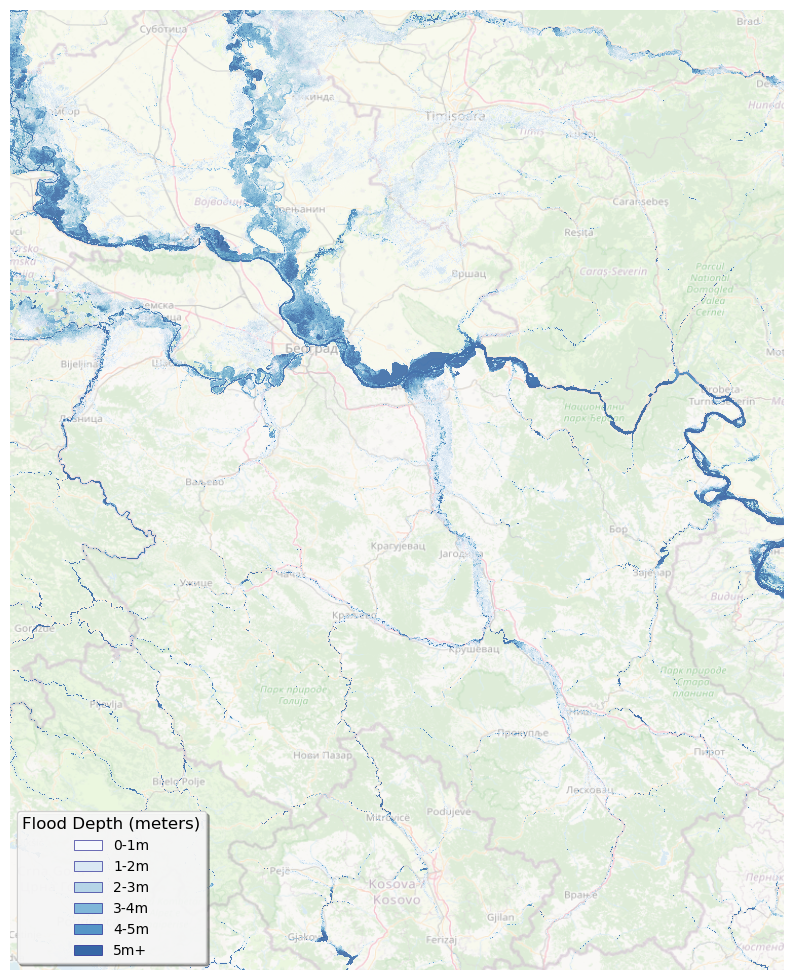

In [4]:
# Flood depth raster map
hazard_country = load_and_clip_flood_raster(data_path / "Europe_RP100_filled_depth.tif", serbia)
plot_flood_depth_map(hazard_country, figure_path, dpi=600)

Roads with flood depth assigned : 2,235
Roads with no flooding          : 3,312
Flood depth range               : 0.10 – 54.62 m


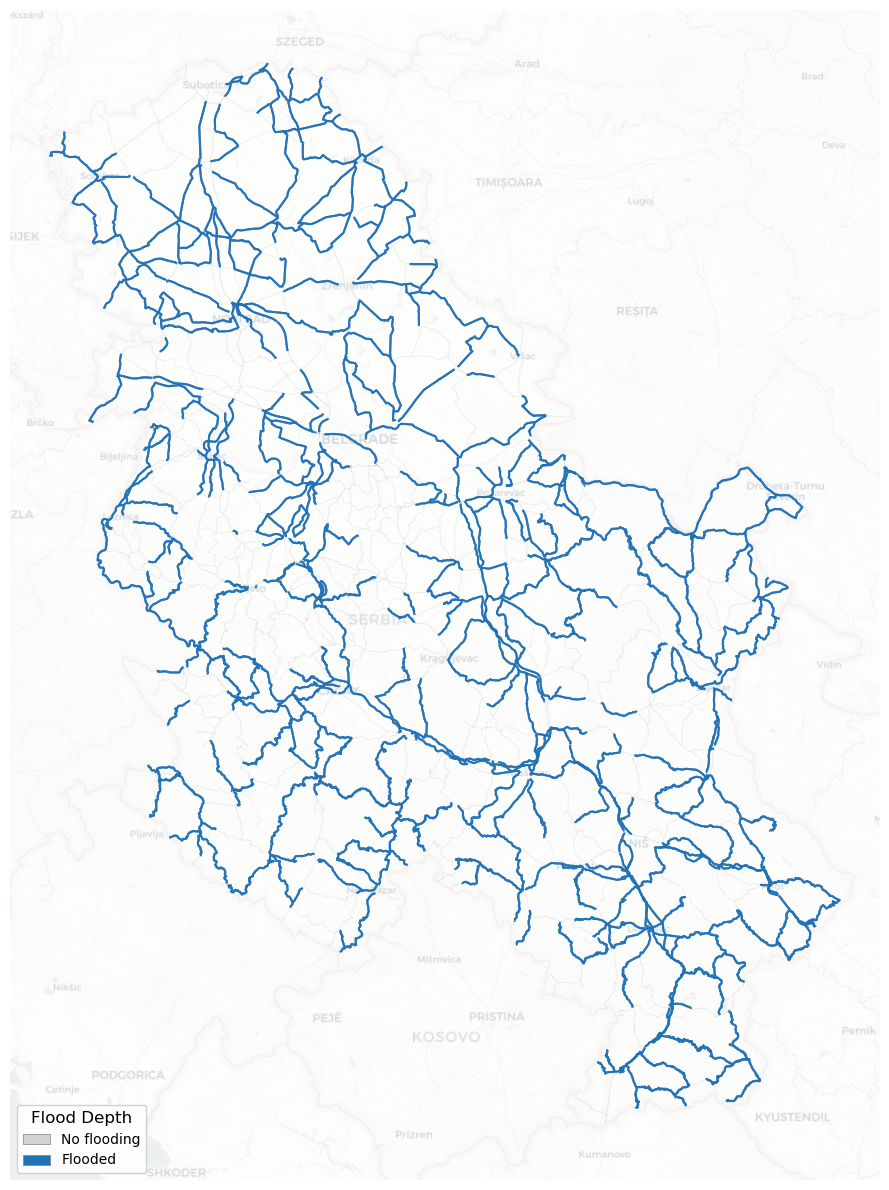

Saved flood_depth_roads -> C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\parquet\hazard_exposure\flood_depth_roads.parquet
Saved flood_depth_roads -> C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\database\hazard_exposure\hazard_exposure.gdb (layer 'flood_depth_roads')
Saved GeoPackage → C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\results\ArcGIS layers\Geopackages\flood_depth_roads.gpkg


In [6]:
# Assign flood depth to processed road network and save + plot
roads = read_road_network(intermediate_results_path / "parquet" / "network" / "main_network_directed.parquet")
roads = assign_flood_depth_to_roads(
    roads=roads,
    raster_data=hazard_country.band_data.values.squeeze(),
    raster_bounds=hazard_country.rio.bounds(),
    raster_crs=hazard_country.rio.crs,
)
roads["flood_class"] = roads["flood_class"].apply(
    lambda x: "No flooding" if x == "No flooding" else "Flooded"
)
plot_flood_depth_roads(
    roads=roads,
    figure_path=figure_path,
    parquet_dir=parquet_dir,
    gdb_path=gdb_path,
    arcgis_gpgk=arcgis_gpgk,
    arcgis_results=arcgis_results,
    output_crs=output_crs,
    dpi=600,
)

c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'
  return ogr_read(


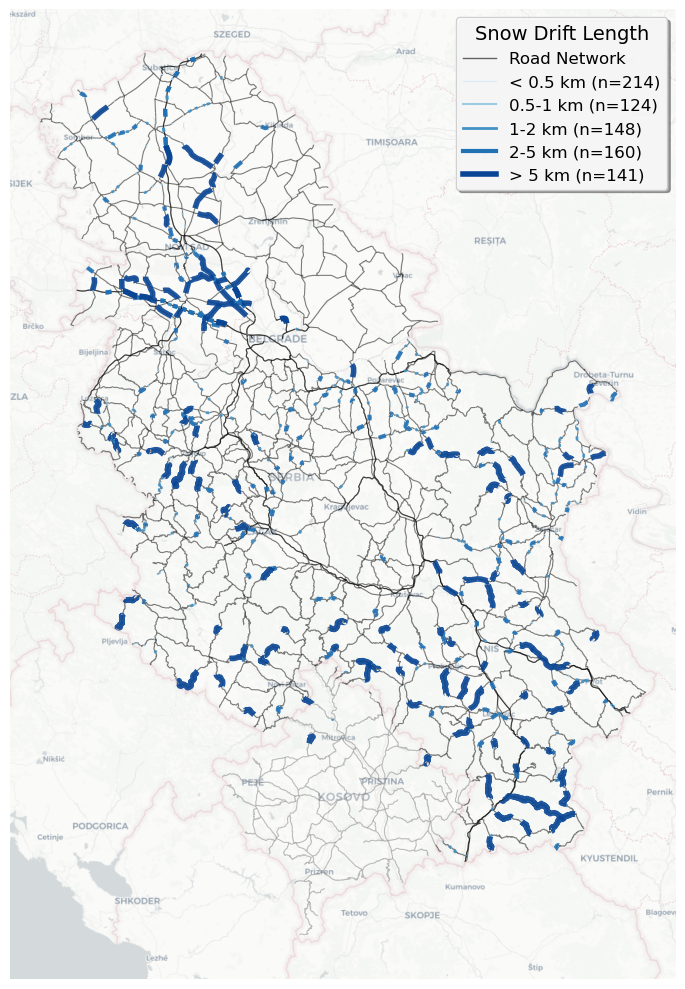

In [7]:
# Snow drift map (length-classified)
plot_snowdrift_map(
    data_path / "snezni_nanosi_studije.shp",
    serbia_roads_mercator, kosovo_roads_mercator,
    figure_path, dpi=600,
)

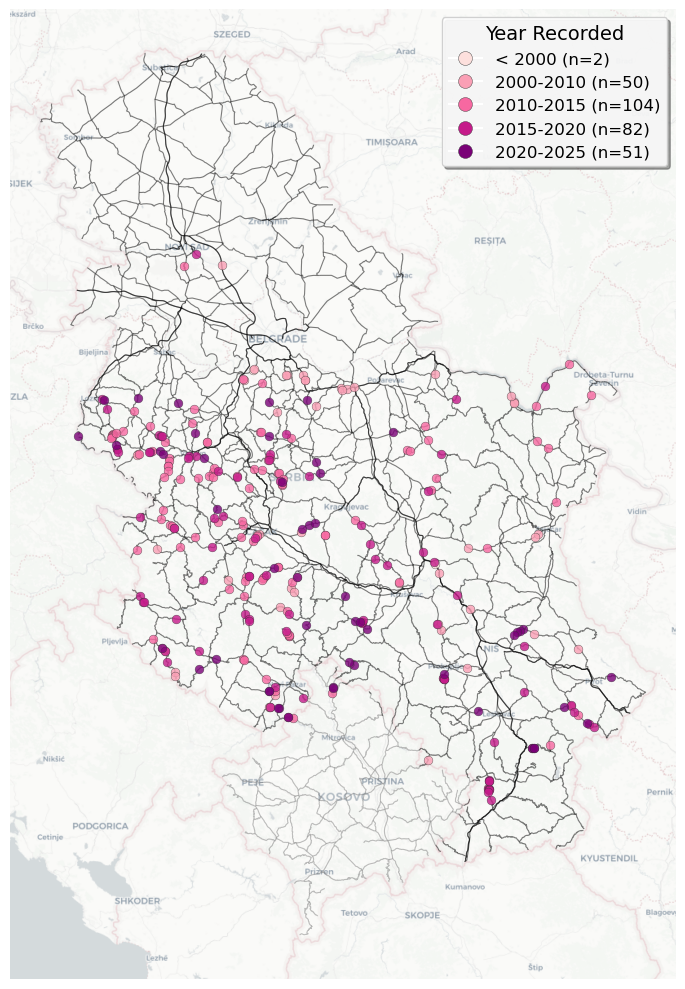

In [8]:
# Landslide map (filtered to Klizište only)
plot_landslides_map(
    data_path / "Nestabilne_pojave.shp",
    serbia_roads_mercator, kosovo_roads_mercator,
    figure_path, dpi=600,
)

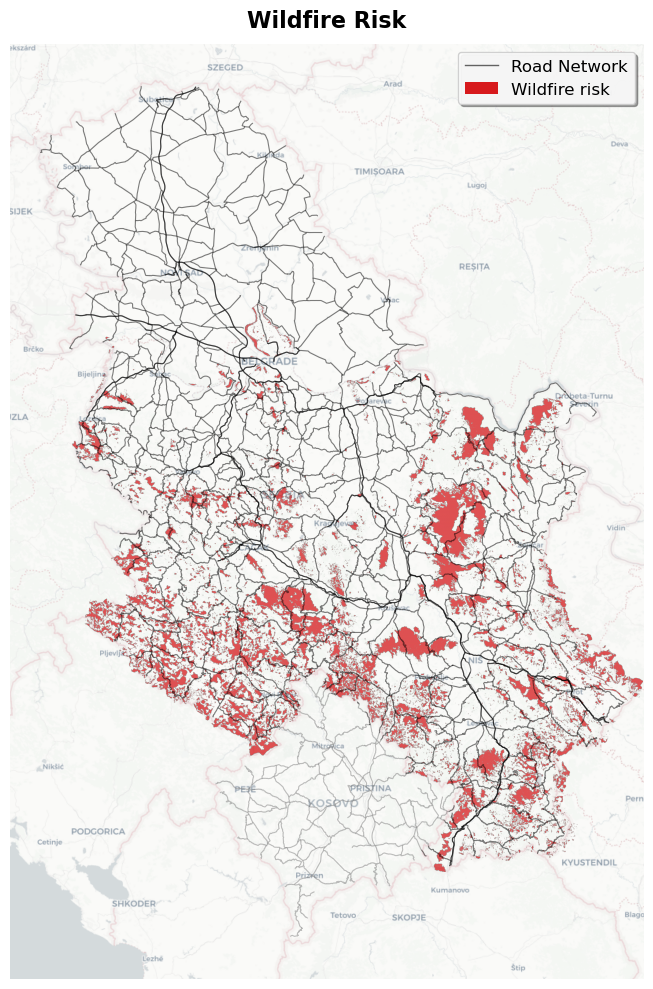

In [9]:
wildfire_path = data_path / "wildfire risk" / "stepen ugrozenosti od pozara Srbijasume.tif"

# Wildfire susceptibility raster map (binary: any class > 0 = risk)
plot_wildfire_raster_map(wildfire_path, serbia_roads_mercator, kosovo_roads_mercator, figure_path, dpi=600)

Wildfire risk distribution:
wildfire_risk
0    1575
1     444
Name: count, dtype: int64


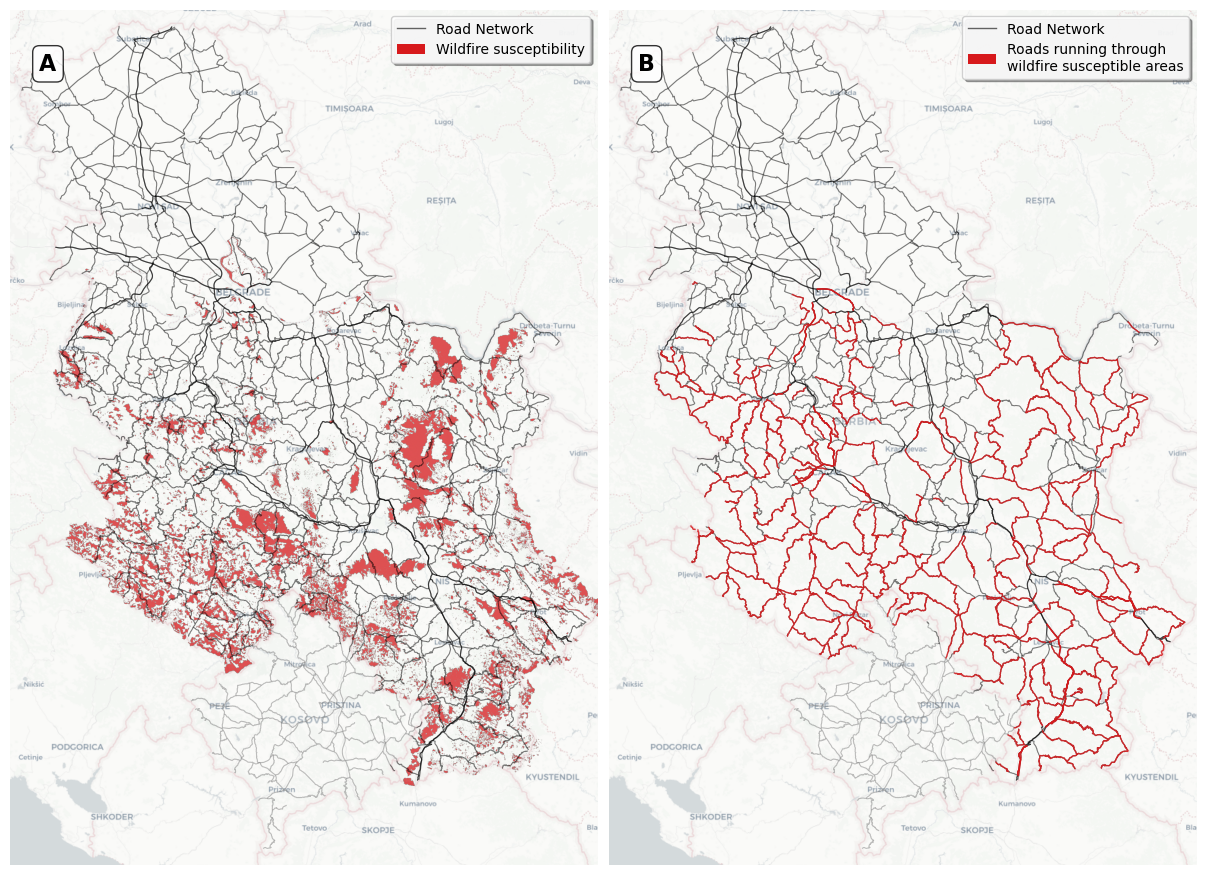

Saved wildfire_risk_roads -> C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\parquet\hazard_exposure\wildfire_risk_roads.parquet
Saved wildfire_risk_roads -> C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\database\hazard_exposure\hazard_exposure.gdb (layer 'wildfire_risk_roads')
Saved GeoPackage → C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\results\ArcGIS layers\Geopackages\wildfire_risk_roads.gpkg


In [10]:
# Assign binary wildfire risk to roads; save to parquet+GDB and plot A/B figure
roads_with_risk = assign_wildfire_risk_to_roads(wildfire_path, baseline_roads, buffer_meters=10)
print(f"Wildfire risk distribution:\n{roads_with_risk['wildfire_risk'].value_counts().sort_index()}")

plot_wildfire_roads_AB(
    wildfire_path=wildfire_path,
    roads_with_risk=roads_with_risk,
    serbia_roads_mercator=serbia_roads_mercator,
    kosovo_roads_mercator=kosovo_roads_mercator,
    figure_path=figure_path,
    parquet_dir=parquet_dir,
    gdb_path=gdb_path,
    arcgis_gpgk=arcgis_gpgk,
    arcgis_results=arcgis_results,
    output_crs=output_crs,
    dpi=600,
)

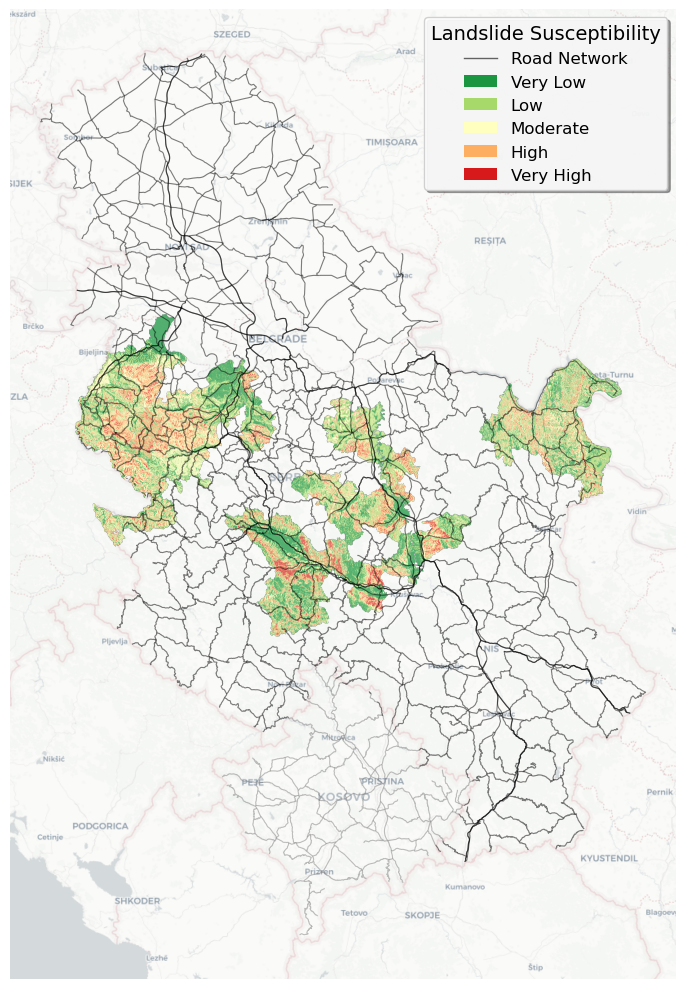

In [11]:
# Landslide susceptibility map
plot_landslide_susceptibility_map(
    data_path / "landslide_susceptibility.tif",
    serbia_roads_mercator, kosovo_roads_mercator,
    figure_path, dpi=600,
)